# Project 6 — CDS Curve Bootstrapping, Default Probabilities and Synthetic CDO Pricing

**Goal.** Build the standard single-name credit toolkit from scratch: take a term structure of CDS par-spread quotes, bootstrap a
piecewise-constant **hazard-rate** curve, derive survival and default probabilities, convert to the post-2009 **upfront + fixed coupon**
convention, compute risk (CS01, bucketed CS01, recovery and jump-to-default risk), and then extend to a **synthetic CDO** on a
125-name index portfolio with the one-factor Gaussian copula, including *why* the market needs a "correlation smile".

**Data.**
* **Discount curve: real.** The US Treasury curve from FRED on the latest available date, bootstrapped to zero rates. (USD CDS
  officially discount on SOFR OIS; the Treasury–SOFR spread is small compared with credit spreads.)
* **CDS quotes: illustrative.** Single-name CDS quotes are proprietary (Markit/ICE/Bloomberg) and aren't in the Massive or Databento
  sets. We use three realistic-looking curves (a high-grade, a high-yield and a distressed issuer) whose *shapes* match what is
  typically observed: upward-sloping for healthy names, inverted for distressed ones. Every number downstream is exact given
  these inputs; drop in real quotes and the code works unchanged.

| § | Content |
|---|---|
| 1 | Reduced-form credit: hazard rates, survival, the credit triangle |
| 2 | Discount curve from the Treasury par curve |
| 3 | CDS pricing engine (premium leg with accrual-on-default, protection leg) |
| 4 | Bootstrapping hazard rates; implied default probabilities |
| 5 | Upfront/coupon convention, CS01, bucketed CS01, recovery & jump-to-default risk |
| 6 | Arbitrage in CDS curves: when the bootstrap breaks |
| 7 | Synthetic CDO: one-factor Gaussian copula, LHP and exact recursion, Monte-Carlo check |
| 8 | The correlation smile: compound and base correlation |
| 9 | Strengths, weaknesses, extensions |

## 1. Reduced-form credit in one page
The default time $\tau$ has hazard rate $\lambda(t)$: $P(\tau\in[t,t+dt)\mid\tau>t)=\lambda(t)dt$. Hence
$$Q(t)=P(\tau>t)=\exp\Big(-\int_0^t\lambda(u)\,du\Big).$$
A **CDS** exchanges a running premium $s$ (paid quarterly on the notional while the name survives) for a payment of $(1-R)$ at default.
With discount factors $D(t)$:
$$\text{Premium leg}=s\cdot\underbrace{\Big[\sum_k\delta_k D(t_k)Q(t_k)+\sum_k\tfrac{\delta_k}{2}D(t_k)\big(Q(t_{k-1})-Q(t_k)\big)\Big]}_{\text{RPV01 (risky annuity), incl. accrual on default}},\qquad
\text{Protection leg}=(1-R)\int_0^T D(t)\,(-dQ(t)).$$
The **par spread** equates the two. For a flat hazard and continuous premium, you get the **credit triangle** $s\approx\lambda(1-R)$: a 100 bp
spread with 40 % recovery means roughly a 1.67 % annual default intensity. **Bootstrapping** reverses the pricing: given par spreads for
6m, 1y, …, 10y, find the piecewise-constant $\lambda$ on each interval that reprices each quote exactly, shortest maturity first.

These are **risk-neutral** probabilities. They include the risk premium investors demand for bearing default risk, so they're
typically several times higher than historical (physical) default rates for investment-grade names.

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm, t as student_t
from IPython.display import display

from qdata import fred_rates

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2. Discount curve
CMT yields up to 1 year are bill (discount-basis) yields, which we treat as annually-compounded zero rates. From 2 years on they are
**par yields** on semi-annual coupon bonds. We interpolate par yields linearly on a 6-month grid and bootstrap discount factors:
$$1=\tfrac{c}{2}\sum_{j=1}^{n}D(t_j)+D(t_n)\;\Rightarrow\;D(t_n)=\frac{1-\tfrac c2\sum_{j<n}D(t_j)}{1+\tfrac c2}.$$
The curve is stored as log-discount factors, interpolated linearly (piecewise-flat forward rates).

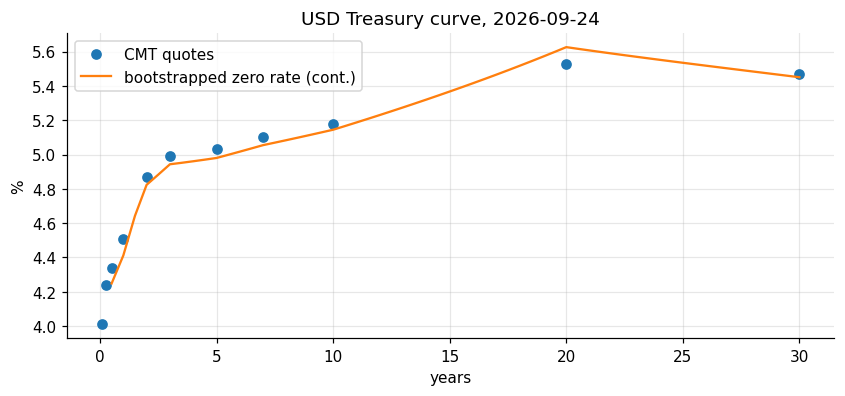

In [2]:
fr = fred_rates()
cols = {"DGS1MO": 1/12, "DGS3MO": .25, "DGS6MO": .5, "DGS1": 1, "DGS2": 2, "DGS3": 3, "DGS5": 5, "DGS7": 7,
        "DGS10": 10, "DGS20": 20, "DGS30": 30}
row = fr[list(cols)].dropna().iloc[-1]
ASOF = row.name
par = pd.Series(row.values / 100, index=list(cols.values()))

grid = np.arange(0.5, 30.01, 0.5)
par_i = np.interp(grid, par.index, par.values)
Dg = np.zeros_like(grid)
for n, (tn, c) in enumerate(zip(grid, par_i)):
    if tn <= 1:
        Dg[n] = (1 + c) ** (-tn)
    else:
        Dg[n] = (1 - c / 2 * Dg[:n].sum()) / (1 + c / 2)
LOGD_T = np.r_[0, grid]; LOGD = np.r_[0, np.log(Dg)]


def D(t):
    t = np.asarray(t, float)
    # log-linear inside the grid; beyond 30y, extend with the average 30y zero rate
    return np.exp(np.where(t <= LOGD_T[-1], np.interp(t, LOGD_T, LOGD), LOGD[-1] / LOGD_T[-1] * t))


zero = -np.log(D(grid)) / grid
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(par.index, par * 100, "o", label="CMT quotes"); ax.plot(grid, zero * 100, "-", label="bootstrapped zero rate (cont.)")
ax.set_xlabel("years"); ax.set_ylabel("%"); ax.set_title(f"USD Treasury curve, {ASOF.date()}"); ax.legend(); plt.show()

## 3. The CDS pricing engine
Standard conventions: quarterly premium payments, ACT/360 accrual ($\delta\approx0.25\times365/360$), **accrual on default** (the protection
buyer pays the premium accrued up to the default date, approximated as half a period), and a protection leg integrated on a weekly grid.
Hazard rates are piecewise constant between the quote maturities (knots).

In [3]:
class HazardCurve:
    def __init__(self, knots, lambdas):
        self.knots = np.asarray(knots, float)          # right end of each interval
        self.lam = np.asarray(lambdas, float)

    def cum(self, t):
        t = np.atleast_1d(np.asarray(t, float))
        left = np.r_[0, self.knots[:-1]]
        # extend the last hazard beyond the last knot
        right = self.knots.copy(); right[-1] = np.inf
        seg = np.clip(t[:, None], left, right) - left
        return (seg * self.lam).sum(1)

    def Q(self, t):
        return np.exp(-self.cum(t))


def cds_legs(curve, T, R=0.4, freq=4, dt_prot=1 / 52):
    pay = np.arange(1, int(round(T * freq)) + 1) / freq
    pay[-1] = T
    prev = np.r_[0, pay[:-1]]
    delta = (pay - prev) * 365 / 360
    Qp, Qprev = curve.Q(pay), curve.Q(prev)
    rpv01 = np.sum(delta * D(pay) * Qp) + np.sum(delta / 2 * D(pay) * (Qprev - Qp))
    tg = np.linspace(0, T, max(int(T / dt_prot), 2) + 1)
    Qg = curve.Q(tg)
    prot = (1 - R) * np.sum(D(0.5 * (tg[1:] + tg[:-1])) * (Qg[:-1] - Qg[1:]))
    return prot, rpv01


def par_spread(curve, T, R=0.4):
    p, a = cds_legs(curve, T, R)
    return p / a


# sanity check: the credit triangle for a flat hazard
flat = HazardCurve([30], [0.02])
print(f"flat λ=2%, R=40%: 5y par spread = {par_spread(flat, 5)*1e4:.1f} bp  (credit triangle λ(1-R) = 120 bp)")

flat λ=2%, R=40%: 5y par spread = 119.1 bp  (credit triangle λ(1-R) = 120 bp)


## 4. Bootstrapping
Three illustrative issuers (par spreads in bp, recovery 40 %):
* **"Aa-industrial"**: tight and upward-sloping (little near-term default risk, uncertainty grows with horizon);
* **"B-rated high yield"**: wide and upward-sloping;
* **"Distressed"**: very wide and **inverted**. The market prices a high chance of default *soon*; conditional on surviving the next
  couple of years, the name is expected to recover.

In [4]:
TENORS = np.array([0.5, 1, 2, 3, 4, 5, 7, 10])
QUOTES = pd.DataFrame({
    "Aa-industrial":      [12, 15, 22, 30, 38, 46, 60, 72],
    "B-rated high yield": [180, 210, 265, 310, 345, 375, 405, 425],
    "Distressed":         [2400, 2100, 1700, 1450, 1300, 1200, 1080, 980],
}, index=TENORS) / 1e4


def bootstrap(tenors, spreads, R=0.4):
    lams = []
    for i, (T, s) in enumerate(zip(tenors, spreads)):
        def f(l):
            c = HazardCurve(tenors[:i + 1], lams + [l])
            p, a = cds_legs(c, T, R)
            return p - s * a
        lo, hi = -0.5, 5.0
        if f(lo) * f(hi) > 0:
            raise ValueError(f"no hazard reprices the {T}y quote")
        lams.append(brentq(f, lo, hi, xtol=1e-12))
    return HazardCurve(tenors, lams)


curves = {n: bootstrap(TENORS, QUOTES[n].values) for n in QUOTES}
tab = []
for n, c in curves.items():
    for T, lam in zip(TENORS, c.lam):
        tab.append({"issuer": n, "tenor": T, "quote (bp)": QUOTES.loc[T, n] * 1e4, "hazard λ on interval": lam,
                    "survival Q(T)": c.Q(T)[0], "cum. default prob": 1 - c.Q(T)[0],
                    "reprice error (bp)": (par_spread(c, T) - QUOTES.loc[T, n]) * 1e4})
tab = pd.DataFrame(tab).set_index(["issuer", "tenor"])
print(f"max |reprice error| = {tab['reprice error (bp)'].abs().max():.2e} bp")
tab.drop(columns="reprice error (bp)")

max |reprice error| = 2.62e-10 bp


quote (bp)  hazard λ on interval  survival Q(T)  \
issuer             tenor                                                      
Aa-industrial      0.5000      12.0000                0.0020         0.9990   
                   1.0000      15.0000                0.0030         0.9975   
                   2.0000      22.0000                0.0049         0.9926   
                   3.0000      30.0000                0.0080         0.9847   
                   4.0000      38.0000                0.0109         0.9740   
                   5.0000      46.0000                0.0140         0.9605   
                   7.0000      60.0000                0.0174         0.9276   
                   10.0000     72.0000                0.0187         0.8769   
B-rated high yield 0.5000     180.0000                0.0303         0.9850   
                   1.0000     210.0000                0.0405         0.9652   
                   2.0000     265.0000                0.0546         0.9139   
                   3.0000     310.0000                0.0698         0.8523   
                   4.0000     345.0000                0.0803         0.7865   
                   5.0000     375.0000                0.0907         0.7183   
                   7.0000     405.0000                0.0882         0.6022   
                   10.0000    425.0000                0.0872         0.4636   
Distressed         0.5000   2,400.0000                0.4037         0.8172   
                   1.0000   2,100.0000                0.2915         0.7064   
                   2.0000   1,700.0000                0.1938         0.5819   
                   3.0000   1,450.0000                0.1209         0.5156   
                   4.0000   1,300.0000                0.1021         0.4656   
                   5.0000   1,200.0000                0.0923         0.4245   
                   7.0000   1,080.0000                0.0881         0.3560   
                   10.0000    980.0000                0.0767         0.2828   

                            cum. default prob  
issuer             tenor                       
Aa-industrial      0.5000              0.0010  
                   1.0000              0.0025  
                   2.0000              0.0074  
                   3.0000              0.0153  
                   4.0000              0.0260  
                   5.0000              0.0395  
                   7.0000              0.0724  
                   10.0000             0.1231  
B-rated high yield 0.5000              0.0150  
                   1.0000              0.0348  
                   2.0000              0.0861  
                   3.0000              0.1477  
                   4.0000              0.2135  
                   5.0000              0.2817  
                   7.0000              0.3978  
                   10.0000             0.5364  
Distressed         0.5000              0.1828  
                   1.0000              0.2936  
                   2.0000              0.4181  
                   3.0000              0.4844  
                   4.0000              0.5344  
                   5.0000              0.5755  
                   7.0000              0.6440  
                   10.0000             0.7172

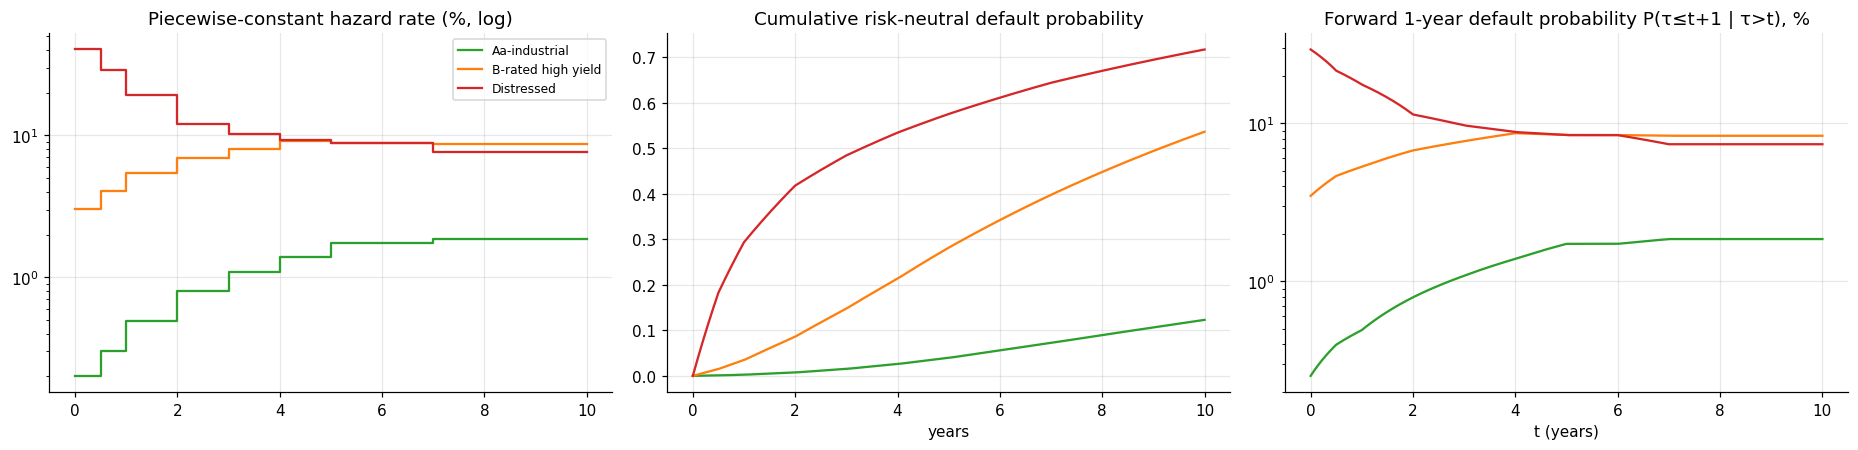

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.2))
tt = np.linspace(0, 10, 501)
for (n, c), col in zip(curves.items(), ["tab:green", "tab:orange", "tab:red"]):
    axs[0].step(np.r_[0, TENORS], np.r_[c.lam[0], c.lam] * 100, where="pre", color=col, label=n)
    axs[1].plot(tt, 1 - c.Q(tt), color=col, label=n)
    # conditional (forward) 1-year default probability: P(τ ≤ t+1 | τ > t)
    fwd1 = 1 - c.Q(tt + 1) / c.Q(tt)
    axs[2].plot(tt, fwd1 * 100, color=col, label=n)
axs[0].set_yscale("log"); axs[0].set_title("Piecewise-constant hazard rate (%, log)"); axs[0].legend(fontsize=8)
axs[1].set_title("Cumulative risk-neutral default probability"); axs[1].set_xlabel("years")
axs[2].set_yscale("log"); axs[2].set_title("Forward 1-year default probability P(τ≤t+1 | τ>t), %"); axs[2].set_xlabel("t (years)")
plt.tight_layout(); plt.show()

**Reading the curves.**
* The healthy names have *rising* hazard rates: default risk is back-loaded. The distressed name has a hazard of 30–40 % a year in the
  first year, and *if it survives*, its conditional default intensity drops sharply. The inverted spread curve is the market saying
  "this company either defaults soon or refinances".
* Cumulative 5-year risk-neutral default probability is a few percent for the Aa name, ~28 % for the HY name and almost 60 % for the
  distressed one. (Compare Moody's historical 5-year default rates: ≈0.3 % for Aa, ≈15–20 % for B. The gap is the credit risk premium.)

## 5. Market conventions and risk
### 5.1 Upfront + fixed coupon
Since the 2009 "Big Bang", single-name CDS trade with a **fixed coupon** $C$ (100 bp for IG, 500 bp for HY) plus an **upfront payment**
settling the difference: $\text{Upfront}=\text{Protection}-C\cdot\text{RPV01}=(s_{par}-C)\cdot\text{RPV01}$ (per unit notional, paid by the
protection buyer when positive). Distressed names trade "points upfront", and the par spread becomes a derived quantity.

In [6]:
conv = []
for n, c in curves.items():
    p, a = cds_legs(c, 5)
    for C in (0.01, 0.05):
        conv.append({"issuer": n, "5y par spread (bp)": p / a * 1e4, "coupon (bp)": C * 1e4, "RPV01": a,
                     "upfront (% notional)": (p - C * a) * 100})
pd.DataFrame(conv).set_index(["issuer", "coupon (bp)"])

5y par spread (bp)  RPV01  \
issuer             coupon (bp)                              
Aa-industrial      100.0000                46.0000 4.4109   
                   500.0000                46.0000 4.4109   
B-rated high yield 100.0000               375.0000 3.9408   
                   500.0000               375.0000 3.9408   
Distressed         100.0000             1,200.0000 2.6902   
                   500.0000             1,200.0000 2.6902   

                                upfront (% notional)  
issuer             coupon (bp)                        
Aa-industrial      100.0000                  -2.3819  
                   500.0000                 -20.0254  
B-rated high yield 100.0000                  10.8372  
                   500.0000                  -4.9260  
Distressed         100.0000                  29.5920  
                   500.0000                  18.8313

### 5.2 Risk measures for a 5y protection-buyer position (\$10 m notional, 100 bp / 500 bp coupon)
* **CS01**: P&L for a +1 bp parallel shift of the quoted spread curve (re-bootstrap, re-price);
* **Bucketed CS01**: the same for each tenor bumped alone. It shows *which* quotes the position is exposed to;
* **Recovery01**: P&L for +1 % recovery, *holding the quoted spreads fixed*. The hazards re-bootstrap, and most of the effect cancels,
  which is why a CDS quoted in spread has small recovery risk until default is near;
* **Jump-to-default (JTD)**: the P&L if the name defaults right now, $(1-R)\cdot N-\text{MTM}$.

In [7]:
N = 10e6


def mtm_buyer(quotes, T=5, C=0.01, R=0.4):
    c = bootstrap(TENORS, quotes, R)
    p, a = cds_legs(c, T, R)
    return (p - C * a) * N


risk = {}
for n in curves:
    q0 = QUOTES[n].values; C = 0.01 if n == "Aa-industrial" else 0.05
    base = mtm_buyer(q0, C=C)
    cs01 = mtm_buyer(q0 + 1e-4, C=C) - base
    buckets = {f"{T:g}y": mtm_buyer(q0 + 1e-4 * (TENORS == T), C=C) - base for T in TENORS}
    rec01 = mtm_buyer(q0, C=C, R=0.41) - base
    risk[n] = {"MTM ($)": base, "CS01 ($/bp)": cs01, "Recovery01 ($/1%)": rec01, "JTD ($)": 0.6 * N - base, **buckets}
risk = pd.DataFrame(risk).T
display(risk[["MTM ($)", "CS01 ($/bp)", "Recovery01 ($/1%)", "JTD ($)"]].style.format("{:,.0f}"))
risk[[f"{T:g}y" for T in TENORS]].style.format("{:,.0f}").background_gradient(axis=1, cmap="Blues")

,MTM ($),CS01 ($/bp),Recovery01 ($/1%),JTD ($)
Aa-industrial,"-238,188","4,505",54,"6,238,188"
B-rated high yield,"-492,599","4,129","1,031","6,492,599"
Distressed,"1,883,127","2,097","-13,981","4,116,873"


,0.5y,1y,2y,3y,4y,5y,7y,10y
Aa-industrial,2,5,15,23,31,"4,430",0,0
B-rated high yield,3,10,28,44,63,"3,981",0,0
Distressed,-7,-23,-72,-132,-213,"2,544",0,0


The bucketed CS01 of a 5-year contract sits almost entirely on the **5y quote** (with small negative/positive amounts on shorter tenors,
since bumping a shorter quote changes the hazard on early intervals, which the 5y bootstrap then offsets). For the distressed name, CS01 is
much smaller per bp: most of the value is already in the upfront, and the position behaves more like a bet on *default vs survival* than on
spreads, so JTD becomes the dominant risk.

## 6. Arbitrage in CDS curves: when the bootstrap breaks
A hazard rate must be non-negative. If a curve is too steep for its level, the bootstrap needs $\lambda<0$ on some interval. That means
*negative forward default probability*: the market would pay you to sell protection on a window in which the name can't
default. It's the credit analogue of butterfly/calendar arbitrage in vol surfaces (Project 1). It's usually a stale or mis-keyed quote, and a
production bootstrapper should detect it rather than silently return a negative hazard.

In [8]:
bad = QUOTES["Aa-industrial"].copy()
bad.loc[3] = 0.0090          # a mis-keyed 3y quote (90 bp instead of 30 bp)
c_bad = bootstrap(TENORS, bad.values)
print("bootstrapped hazards with a bad 3y quote:", np.round(c_bad.lam * 1e4, 1), "bp")
neg = TENORS[c_bad.lam < 0]
print(f"→ negative hazard on the interval(s) ending at {neg} years: forward default probability < 0, i.e. arbitrage")

bootstrapped hazards with a bad 3y quote: [  20.2   30.4   49.3  403.8 -234.1  139.3  173.8  186.7] bp
→ negative hazard on the interval(s) ending at [4.] years: forward default probability < 0, i.e. arbitrage


## 7. Synthetic CDOs on a credit index
A synthetic CDO slices the loss of a reference portfolio of CDS into **tranches** $[A,D]$. The tranche absorbs portfolio losses between the
attachment $A$ and detachment $D$:
$$L_{[A,D]}(t)=\frac{\min\big(\max(L(t)-A,0),\,D-A\big)}{D-A}.$$
Tranche legs are like a CDS with the survival probability replaced by the tranche's expected outstanding notional:
$$\text{Prot}=\sum_k D(t_k)\big(E L_{tr}(t_k)-EL_{tr}(t_{k-1})\big),\quad\text{RPV01}=\sum_k\delta_k D(t_k)\Big(1-\tfrac{EL_{tr}(t_k)+EL_{tr}(t_{k-1})}{2}\Big).$$
All we need is the **distribution of portfolio loss** at each date, which requires a model of **default dependence**.

**One-factor Gaussian copula** (Li 2000; Vasicek 1987): name $i$ defaults by $t$ if $X_i=\sqrt\rho\,M+\sqrt{1-\rho}\,\varepsilon_i\le\Phi^{-1}(PD_i(t))$,
with a common factor $M$ and idiosyncratic $\varepsilon_i$. Conditional on $M$, defaults are independent:
$$p_i(t\mid M)=\Phi\Big(\frac{\Phi^{-1}(PD_i(t))-\sqrt\rho M}{\sqrt{1-\rho}}\Big).$$
Loss distribution: (a) **LHP** (Vasicek large homogeneous pool, closed form); (b) **exact recursion** over names conditional on $M$
(Andersen–Sidenius–Basu 2003), integrated over $M$ with Gauss–Hermite quadrature; (c) **Monte Carlo** as a check.

**Portfolio.** 125 names, equal notional, R = 40 %. The 5y spreads are *illustrative*: lognormally dispersed around ~70 bp, like a
CDX-IG-type index. Each name gets a flat hazard (bootstrapped from its 5y quote). Tranches follow the CDX-IG convention:
0–3 %, 3–7 %, 7–15 %, 15–100 %.

In [9]:
rng = np.random.default_rng(7)
NN, R_ = 125, 0.4
s5 = np.exp(rng.normal(np.log(0.0060), 0.55, NN))            # 5y spreads, median 60 bp
lam_i = np.array([bootstrap(np.array([5.0]), [s]).lam[0] for s in s5])     # flat hazard reprising each 5y quote
PAY = np.arange(1, 21) / 4                                    # quarterly to 5y
PD = 1 - np.exp(-np.outer(lam_i, PAY))                        # (names, dates)
TR = [(0.0, 0.03), (0.03, 0.07), (0.07, 0.15), (0.15, 1.0)]
print(f"index: median 5y spread {np.median(s5)*1e4:.0f} bp, mean {s5.mean()*1e4:.0f} bp, max {s5.max()*1e4:.0f} bp; "
      f"expected 5y portfolio loss {(PD[:, -1] * (1 - R_)).mean():.2%}")

GH_X, GH_W = np.polynomial.hermite_e.hermegauss(60)          # quadrature for M ~ N(0,1)
GH_W = GH_W / GH_W.sum()
LGD_UNIT = (1 - R_) / NN


def loss_dist_given_p(p):
    """Exact distribution of the number of defaults for independent Bernoullis with probs p (recursion)."""
    dist = np.zeros(len(p) + 1); dist[0] = 1.0
    for pi in p:
        dist[1:] = dist[1:] * (1 - pi) + dist[:-1] * pi
        dist[0] *= (1 - pi)
    return dist


def tranche_el_gauss(rho, pd_names=PD, tranches=TR):
    """Expected tranche loss (fraction of tranche notional) at each payment date, one-factor Gaussian copula, exact recursion."""
    thr = norm.ppf(np.clip(pd_names, 1e-15, 1 - 1e-15))
    k = np.arange(NN + 1) * LGD_UNIT
    out = np.zeros((len(tranches), pd_names.shape[1]))
    for m, w in zip(GH_X, GH_W):
        pc = norm.cdf((thr - np.sqrt(rho) * m) / np.sqrt(1 - rho))
        for j in range(pd_names.shape[1]):
            dist = loss_dist_given_p(pc[:, j])
            for ti, (A, Dd) in enumerate(tranches):
                out[ti, j] += w * np.sum(dist * np.clip(k - A, 0, Dd - A)) / (Dd - A)
    return out


def tranche_el_lhp(rho, tranches=TR):
    """Vasicek large homogeneous pool with the average PD: closed-form conditional loss, integrate over M."""
    pbar = PD.mean(0)
    out = np.zeros((len(tranches), len(PAY)))
    for m, w in zip(GH_X, GH_W):
        L = (1 - R_) * norm.cdf((norm.ppf(pbar) - np.sqrt(rho) * m) / np.sqrt(1 - rho))
        for ti, (A, Dd) in enumerate(tranches):
            out[ti] += w * np.clip(L - A, 0, Dd - A) / (Dd - A)
    return out


def tranche_prices(EL):
    """Par spread (bp) and, for equity, upfront with 500 bp running."""
    delta = np.full(len(PAY), 0.25 * 365 / 360)
    Dp = D(PAY)
    ELp = np.hstack([np.zeros((EL.shape[0], 1)), EL])
    prot = (Dp * np.diff(ELp, axis=1)).sum(1)
    rpv = (delta * Dp * (1 - 0.5 * (ELp[:, 1:] + ELp[:, :-1]))).sum(1)
    return prot, rpv


t0 = time.time()
rho0 = 0.30
EL_g = tranche_el_gauss(rho0)
EL_l = tranche_el_lhp(rho0)
print(f"exact recursion: {time.time()-t0:.1f}s")

# Monte-Carlo check of the recursion
nsim = 100_000
M_ = rng.standard_normal(nsim).astype(np.float32)
thr5 = norm.ppf(PD).astype(np.float32)
EL_mc = np.zeros((len(TR), len(PAY)))
for chunk in range(10):
    m = M_[chunk * 10_000:(chunk + 1) * 10_000]
    X = np.sqrt(rho0) * m[:, None] + np.sqrt(1 - rho0) * rng.standard_normal((len(m), NN)).astype(np.float32)
    for j in range(len(PAY)):
        L = (X <= thr5[:, j]).sum(1) * LGD_UNIT
        for ti, (A, Dd) in enumerate(TR):
            EL_mc[ti, j] += np.clip(L - A, 0, Dd - A).sum() / (Dd - A) / nsim

rows = []
for name, EL in [("LHP (Vasicek)", EL_l), ("exact recursion", EL_g), ("Monte Carlo 100k", EL_mc)]:
    p, a = tranche_prices(EL)
    for ti, (A, Dd) in enumerate(TR):
        r = {"method": name, "tranche": f"{A:.0%}–{Dd:.0%}", "5y expected tranche loss": EL[ti, -1], "par spread (bp)": p[ti] / a[ti] * 1e4}
        if A == 0:
            r["upfront @500bp running (%)"] = (p[ti] - 0.05 * a[ti]) * 100
        rows.append(r)
pd.DataFrame(rows).set_index(["tranche", "method"]).sort_index()

index: median 5y spread 56 bp, mean 61 bp, max 206 bp; expected 5y portfolio loss 2.98%


exact recursion: 0.5s


5y expected tranche loss  par spread (bp)  \
tranche  method                                                        
0%–3%    LHP (Vasicek)                       0.5382       1,581.8113   
         Monte Carlo 100k                    0.5323       1,550.1971   
         exact recursion                     0.5315       1,547.6279   
15%–100% LHP (Vasicek)                       0.0015           2.8285   
         Monte Carlo 100k                    0.0015           2.7752   
         exact recursion                     0.0014           2.6492   
3%–7%    LHP (Vasicek)                       0.1932         406.9141   
         Monte Carlo 100k                    0.1997         423.0407   
         exact recursion                     0.2005         424.6030   
7%–15%   LHP (Vasicek)                       0.0586         113.6409   
         Monte Carlo 100k                    0.0587         114.3367   
         exact recursion                     0.0585         113.7355   

                           upfront @500bp running (%)  
tranche  method                                        
0%–3%    LHP (Vasicek)                        33.2876  
         Monte Carlo 100k                     32.5752  
         exact recursion                      32.5073  
15%–100% LHP (Vasicek)                            NaN  
         Monte Carlo 100k                         NaN  
         exact recursion                          NaN  
3%–7%    LHP (Vasicek)                            NaN  
         Monte Carlo 100k                         NaN  
         exact recursion                          NaN  
7%–15%   LHP (Vasicek)                            NaN  
         Monte Carlo 100k                         NaN  
         exact recursion                          NaN

The exact recursion and Monte Carlo agree to within simulation noise. LHP is close for the mezzanine and senior tranches but misprices
the equity tranche, because it ignores the **dispersion** of spreads across names: a few wide names dominate early losses, and they
land in the equity tranche.

**Loss conservation check.** A long position in every tranche, weighted by its thickness, is the whole index. The notional-weighted sum of
tranche expected losses must equal the index expected loss at every date:

Σ (thickness × tranche EL) at 5y = 0.029850;   index EL = 0.029850


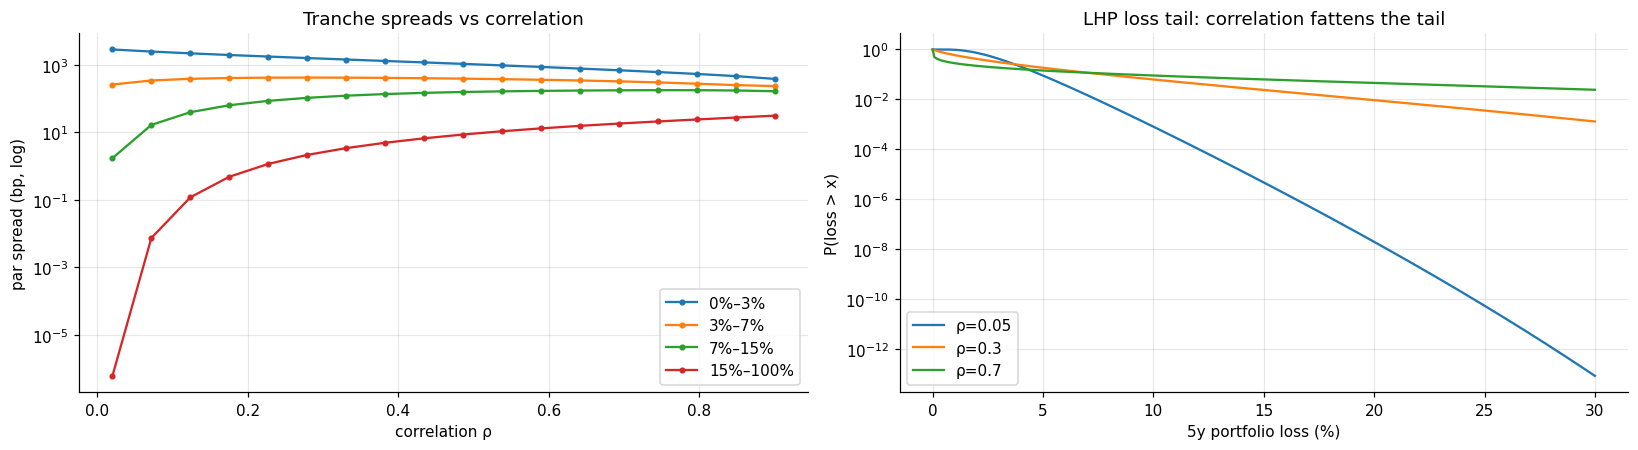

In [10]:
w_tr = np.array([Dd - A for A, Dd in TR])
print(f"Σ (thickness × tranche EL) at 5y = {(w_tr * EL_g[:, -1]).sum():.6f};   index EL = {(PD[:, -1] * (1 - R_)).mean():.6f}")

fig, axs = plt.subplots(1, 2, figsize=(15, 4.2))
rhos = np.linspace(0.02, 0.9, 18)
spr = np.array([(lambda pa: pa[0] / pa[1])(tranche_prices(tranche_el_gauss(r))) for r in rhos]) * 1e4
for ti, (A, Dd) in enumerate(TR):
    axs[0].plot(rhos, spr[:, ti], "o-", ms=3, label=f"{A:.0%}–{Dd:.0%}")
axs[0].set_yscale("log"); axs[0].set_xlabel("correlation ρ"); axs[0].set_ylabel("par spread (bp, log)")
axs[0].set_title("Tranche spreads vs correlation"); axs[0].legend()
x = np.linspace(0, 0.3, 400)
for r in (0.05, 0.3, 0.7):
    pbar = PD[:, -1].mean()
    cdf = norm.cdf((np.sqrt(1 - r) * norm.ppf(np.clip(x / (1 - R_), 1e-12, 1 - 1e-12)) - norm.ppf(pbar)) / np.sqrt(r))
    axs[1].plot(x * 100, 1 - cdf, label=f"ρ={r}")
axs[1].set_yscale("log"); axs[1].set_xlabel("5y portfolio loss (%)"); axs[1].set_ylabel("P(loss > x)")
axs[1].set_title("LHP loss tail: correlation fattens the tail"); axs[1].legend()
plt.tight_layout(); plt.show()

**Correlation is the key risk factor of a CDO.**
* **Equity (0–3 %) is long correlation**: higher correlation → more scenarios with *no* defaults → cheaper equity protection.
* **Senior (15–100 %) is short correlation**: only a high-correlation world produces losses large enough to reach it.
* **Mezzanine** is non-monotonic in correlation, which is why a single mezz price can map to *two* correlations (see below).

## 8. The correlation smile: compound and base correlation
If the Gaussian copula were the true model, one correlation would reprice every tranche. In real markets it doesn't: the implied
correlation differs by tranche. On CDX/iTraxx, **base correlation rises steeply with the detachment point** (the "correlation skew").
We have no proprietary tranche quotes, so we explain the skew by generating stand-in "market" prices from richer dependence models,
then inverting the Gaussian model tranche by tranche:
* **Compound correlation**: the single ρ that reprices tranche $[A,D]$ on its own. It can fail to exist or be non-unique for mezzanine tranches.
* **Base correlation** (McGinty et al. 2004): the ρ that reprices the equity-like tranche $[0,D]$ for each detachment $D$. It's always unique,
  because $[0,D]$ is monotone in ρ. Tranche $[A,D]$ is then priced as $[0,D]-[0,A]$ with two different correlations.

Two candidate "markets", both with exactly the same single-name default probabilities:
1. **Systemic-state (stochastic) correlation** (Burtschell, Gregory & Laurent 2007): with probability $q=10\%$ the economy is in a *systemic* state where
   asset correlation is $\rho_H=0.85$, otherwise $\rho_L=0.15$. It's a mixture of Gaussian copulas, so we can price it exactly with the same recursion.
2. **Student-t copula** ($\nu=4$, ρ = 0.30): symmetric tail dependence, priced by Monte Carlo.


'Market' = systemic-state


,spread (bp),compound ρ
0%–3%,"1,875.6179",0.20
3%–7%,388.4329,"0.12, 0.51"
7%–15%,64.4366,0.18
15%–100%,3.0052,0.31



'Market' = t-copula


,spread (bp),compound ρ
0%–3%,"1,040.9226",0.51
3%–7%,396.6878,"0.14, 0.48"
7%–15%,163.8459,"0.52, 0.91"
15%–100%,8.8999,0.49


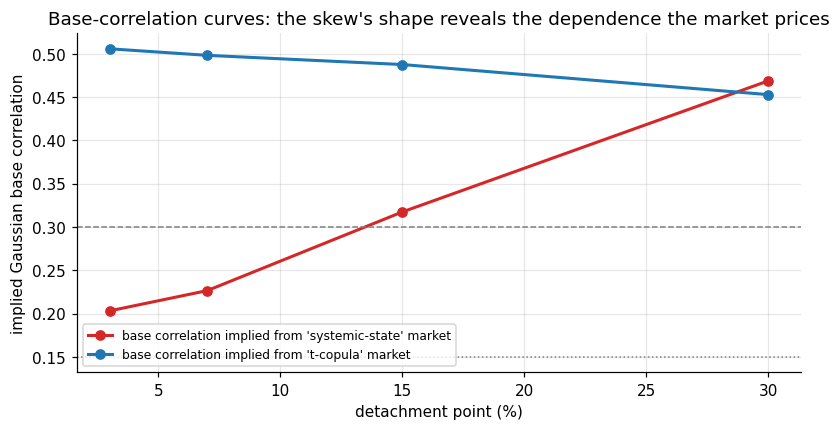

,0–3%,0–7%,0–15%,0–30%
systemic-state,0.2031,0.2265,0.3174,0.4688
t-copula,0.5059,0.4983,0.4877,0.4529


In [11]:
Q_SYS, RHO_L, RHO_H = 0.10, 0.15, 0.85
DETS = [0.03, 0.07, 0.15, 0.30]
base_tr = [(0.0, d) for d in DETS]
allt = TR + base_tr


def el_systemic(tranches):
    return Q_SYS * tranche_el_gauss(RHO_H, tranches=tranches) + (1 - Q_SYS) * tranche_el_gauss(RHO_L, tranches=tranches)


EL_sys = el_systemic(allt)

nu, nsim_t = 4, 200_000
rng_t = np.random.default_rng(11)
thr_t = student_t.ppf(np.clip(PD, 1e-12, 1 - 1e-12), df=nu)        # thresholds on the t-distributed latent variable
EL_t = np.zeros((len(allt), len(PAY)))
for chunk in range(20):
    n = nsim_t // 20
    W = rng_t.chisquare(nu, n) / nu
    Z = (np.sqrt(rho0) * rng_t.standard_normal(n)[:, None] + np.sqrt(1 - rho0) * rng_t.standard_normal((n, NN))) / np.sqrt(W)[:, None]
    for j in range(len(PAY)):
        L = (Z <= thr_t[:, j]).sum(1) * LGD_UNIT
        for ti, (A, Dd) in enumerate(allt):
            EL_t[ti, j] += np.clip(L - A, 0, Dd - A).sum() / (Dd - A) / nsim_t


def implied_rho(target_spread, tranche):
    def f(r):
        p, a = tranche_prices(tranche_el_gauss(r, tranches=[tranche]))
        return p[0] / a[0] - target_spread
    grid_r = np.linspace(0.01, 0.97, 25)
    vals = np.array([f(r) for r in grid_r])
    return [brentq(f, grid_r[i], grid_r[i + 1]) for i in range(len(grid_r) - 1) if vals[i] * vals[i + 1] < 0]


results = {}
for mname, EL_m in [("systemic-state", EL_sys), ("t-copula", EL_t)]:
    pm, am = tranche_prices(EL_m)
    comp = {f"{tr[0]:.0%}–{tr[1]:.0%}": {"spread (bp)": pm[ti] / am[ti] * 1e4,
                                         "compound ρ": ", ".join(f"{r:.2f}" for r in implied_rho(pm[ti] / am[ti], tr)) or "none"}
            for ti, tr in enumerate(TR)}
    basec = {tr[1]: (implied_rho(pm[len(TR) + bi] / am[len(TR) + bi], tr) or [np.nan])[0] for bi, tr in enumerate(base_tr)}
    results[mname] = (pd.DataFrame(comp).T, pd.Series(basec))
    print(f"\n'Market' = {mname}")
    display(results[mname][0])

fig, ax = plt.subplots(figsize=(8.5, 4))
for (mname, (_, bc)), col in zip(results.items(), ["tab:red", "tab:blue"]):
    ax.plot(np.array(bc.index) * 100, bc.values, "o-", lw=2, color=col, label=f"base correlation implied from '{mname}' market")
ax.axhline(RHO_L, color="grey", ls=":", lw=1); ax.axhline(rho0, color="grey", ls="--", lw=1)
ax.set_xlabel("detachment point (%)"); ax.set_ylabel("implied Gaussian base correlation"); ax.legend(fontsize=8)
ax.set_title("Base-correlation curves: the skew's shape reveals the dependence the market prices"); plt.show()
pd.DataFrame({k: v[1] for k, v in results.items()}).T.rename(columns=lambda d: f"0–{d:.0%}")

**Interpretation.**
* With the **systemic-state** market, the implied base correlation **rises with detachment**, the shape seen in real index-tranche markets.
  Equity losses are driven by ordinary, low-correlation times, so equity implies a low ρ. Senior tranches lose only in the rare
  systemic state, and the Gaussian model can reproduce that tail only by cranking ρ up.
* The **t-copula** market produces a curve that is high everywhere but *falling* with detachment. Its tail dependence is symmetric: it creates
  extra "nobody defaults" scenarios as well as extra crashes, which makes equity look very highly correlated too.
* Mezzanine tranches can have **two** compound correlations (or none), which is why the market moved to base correlation as the quoting convention.
* **Lesson.** The correlation skew isn't a curiosity of quoting. It's the market pricing **correlation that rises in bad states**
  (systemic risk), which a single-ρ Gaussian copula cannot represent. That's the same blind spot that made super-senior mortgage-CDO tranches look
  nearly riskless before 2007.

## 9. Strengths, weaknesses and extensions
**Strengths**
* The single-name bootstrap is exact, fast and standard (it mirrors the ISDA CDS Standard Model's piecewise-flat hazard/forward structure).
* Risk-neutral default probabilities fall directly out of market quotes, and bucketed CS01 maps risk to hedgeable instruments.
* The one-factor copula with exact recursion prices heterogeneous portfolios in seconds, and loss conservation gives a built-in consistency check.
* Base correlation gives the market a *quoting* convention that is unique and interpolable across detachments.

**Weaknesses**
* **Illustrative quotes**: with real data you'd also need the ISDA date conventions exactly (IMM roll dates, T+1 step-in, business-day
  adjustments, the ISDA standard model's discounting), and a SOFR OIS curve rather than Treasuries.
* **Deterministic recovery and independence of rates and default**: in reality recoveries fall when defaults cluster, and wrong-way risk matters.
* **The Gaussian copula is static and has no tail dependence.** It has no dynamics, so it can't price forward-starting tranches or options on tranches,
  and it understates joint crash risk. That was the famous failure of 2007–08, when senior tranches of mortgage CDOs rated AAA under
  Gaussian-copula-type assumptions took large losses.
* **Base correlation isn't arbitrage-free**: interpolating it across detachments can produce negative tranche expected-loss increments.

**Extensions**
* Random-recovery copulas (Andersen–Sidenius 2004); stochastic or local correlation; Marshall–Olkin / Lévy copulas for tail dependence.
* Dynamic top-down models of portfolio loss (Schönbucher; Giesecke), or bottom-up intensity models with common jumps.
* Structural-model (Merton / Black–Cox) implied spreads for real companies, using equity data (market cap and equity volatility from
  Massive, liabilities from `curated/sec_facts`), as a proxy "quote" when no CDS trades.
* Index–constituent basis: compare the index spread with the average of single-name spreads (skew adjustment).

**References.** O'Kane, *Modelling Single-name and Multi-name Credit Derivatives* (2008); Hull & White, "Valuation of a CDO and an nth-to-default
CDS without Monte Carlo" (2004); Andersen, Sidenius & Basu, "All your hedges in one basket", *Risk* (2003); Li, "On default correlation: a copula
function approach" (2000); McGinty, Beinstein, Ahluwalia & Watts, "Introducing base correlations", JP Morgan (2004); ISDA CDS Standard Model.